# PSR J0537-6910 — Modelo vs Datos Observacionales

Este notebook compara el modelo de rotación del púlsar (obtenido del archivo `.par`) con datos observacionales independientes (archivo `.dat`).

## Modelo teórico

La frecuencia de rotación se describe como expansión de Taylor:

$$F_0(t) = F_0 + F_1 t' + \frac{1}{2}F_2 t'^2 + \frac{1}{6}F_3 t'^3 + \sum_i \Delta F_{0,i}(t)$$

$$F_1(t) = F_1 + F_2 t' + \frac{1}{2}F_3 t'^2 + \sum_i \Delta F_{1,i}(t)$$

donde $t' = (t - \text{PEPOCH})$ en segundos y los términos $\Delta F_{0,i}$, $\Delta F_{1,i}$ son las contribuciones de cada glitch.

## Modelo de glitches

Cada glitch $i$ ocurre en la época $t_{g,i}$ (GLEP) y produce saltos permanentes en $F_0$ y $F_1$. Para $t > t_{g,i}$, su contribución es:

$$\Delta F_{0,i}(t) = \text{GLF0}_i + \text{GLF1}_i \cdot (t - t_{g,i}) + \frac{1}{2}\text{GLF2}_i \cdot (t - t_{g,i})^2$$

$$\Delta F_{1,i}(t) = \text{GLF1}_i + \text{GLF2}_i \cdot (t - t_{g,i})$$

Físicamente: un glitch es un aumento abrupto en $F_0$ (el púlsar gira de repente más rápido), seguido de una relajación gradual mediada por $\text{GLF1}_i < 0$ (frenado post-glitch más intenso).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import re

# ── Configuración central del notebook ─────────────────────────────────────
CONFIG = {
    #Diccionario creado para declarar los parametros a usar en el funcionamiento del programa
    'PAR_FILE': 'par_files/nicer-paper.par', #Selección del archivo .par
    'DAT_FILE': 'dat_files/nicervf_sm5-20.dat', #Selección del archivo .dat
    'USAR_GLITCHES': True, #Usar o no los glitches encontrados dentro del set de datos
    'GLITCHES_IGNORAR': [], #Seleccionar Glitches a ignorar
}

---
## 1. Lectura del archivo `.par`

Se extraen los parámetros de rotación base ($F_0, F_1, F_2, F_3$, PEPOCH) y los parámetros de cada glitch (GLEP, GLF0, GLF1, GLF2).

Se muestra además un resumen de parámetros y glitches detectados, con validación básica de campos faltantes.

In [ ]:
def leer_par(filename):
    """
    Funcion que lee el archivo .par y extrae los parametros a usar junto con sus respectivos glitches

    Parámetros:
        filename (str): ruta del archivo .par
    Retorna:
        params (dict): Parametros encontrados con la lista de glitches
        Reporte (dict):Resumen del proceso de lectura:
                       -Cantidad de lineas procesadas
                       -Erorres
                       -Glitches incompletos 
    """

    params = {} #Almacenar parametros del archivo
    glitches_raw = {} #Almacenar datos de cada glitch
    reporte = { 
        #Estadisticas del proceso de lectura
        'lineas_leidas': 0, #Lineas revisadas del archivo
        'lineas_validas': 0, #Lineas con la informacion necesaria para analizar la rotacion
        'parametros_invalidos': 0, #Valores que no pudieron convertirse a numero
        'glitches_incompletos': 0, #Glitches sin valor de GLEP (Sin valor de la epoca donde ocurrieron)
    }

    with open(filename, 'r', encoding='utf-8') as f: #Abrir archivo (lectura "r") 
        for line in f:
            reporte['lineas_leidas'] += 1 #Por linea leida aumenta en 1 el valor de la clave (clave:valor)
            line = re.sub(r'\\', '', line).strip() #Se buscan barras invertidas y se reemplazan con un vacio (re.sub(valor,reemplazo,linea)) y ademas se eliminan del principio y final espacios en blanco, tabulaciones y saltos de linea (.strip) 
            if not line or line.startswith('#'): #Comprobar que la linea no esté vacia o comentada
                continue #Si se cumple, salta la linea

            parts = line.split() #Se divide la linea en elementos separados por espacios
            if len(parts) < 2: #Si la linea tiene menos de 2 valores
                continue #Salta esa linea

            reporte['lineas_validas'] += 1 #Luego de verificar las lineas, aumenta en 1 el contador de las lineas validas
            key, val_str = parts[0], parts[1] #Se guarda la clave y valor de la linea validada

            m = re.match(r'(GLEP|GLF0|GLF1|GLF2)_(\d+)', key) #Verificar que la clave corresponda a un parametro de glitch (re.match) (GLEP_1)
            if m: #Si encuentra un parametro relacionado con un glitch
                gl_param = m.group(1) #Obtener tipo de parametro (GLEP|GLF0|GLF1|GLF2)
                gl_idx = int(m.group(2)) #Obtener a cual glitch se refieren los datos (_1)
                glitches_raw.setdefault(gl_idx, {}) #Crea un diccionario vacio para el glitch si la clave aun no esta registrada (si lo está, no cambia el valor de la clave y pasa a la siguiente linea)  
                try:
                    glitches_raw[gl_idx][gl_param] = float(val_str) #Guarda el valor del parametro del glitch
                except ValueError:
                    reporte['parametros_invalidos'] += 1 #Suma un error si no se puede convertir el valor a float
                continue

            try:
                if ':' not in val_str: #Verificar que el texto no contenga ":" (ej: RAJ)
                    params[key] = float(val_str) #Guarda el parametro conviertiendo el valor a numero flotante
            except ValueError:
                reporte['parametros_invalidos'] += 1 #Suma un error si el valor no se puede convertir

    glitches = [glitches_raw[i] for i in sorted(glitches_raw)] #Ordenar los glitches y convertirlo en lista

    for g in glitches: #Por cada glitch
        if 'GLEP' not in g: #Si el glitch no posee una epoca donde ocurrió
            reporte['glitches_incompletos'] += 1 #Suma un glitch incompleto a la clave

    params['glitches'] = glitches #Se agrega la lista de glitches al diccionario de los parametros
    return params, reporte #Se devuelven los parametros y el reporte


---
## 2. Lectura del archivo `.dat`

El archivo `.dat` contiene valores observacionales con las columnas:

| Col | Descripción | Unidades originales | Factor de escala |
|-----|-------------|---------------------|------------------|
| 0   | MJD         | días                | —                |
| 1   | F0          | Hz                  | ×1               |
| 2   | err_F0      | Hz                  | ×1               |
| 3   | F1          | 1×10⁻¹⁵ Hz/s        | ×1×10⁻¹⁵         |
| 4   | err_F1      | 1×10⁻¹⁵ Hz/s        | ×1×10⁻¹⁵         |
| 5   | F2          | 1×10⁻²⁴ Hz/s²       | ×1×10⁻²⁴         |
| 6   | err_F2      | 1×10⁻²⁴ Hz/s²       | ×1×10⁻²⁴         |

In [ ]:
def leer_dat(filename):
    '''
    Funcion que lee el archivo .dat y extrae sus datos de frecuencia, datos temporales y errores asociados

    Parametros:
        filename (str): ruta del archivo .dat
    Retorna:
        datos (dict): diccionario con los datos procesados convertidos en arrays de numpy
        reporte (dict): resumen de la lectura:
                       -Cantidad de lineas procesadas
                       -Cantidad de lineas utilizadas
                       -Cantidad de lineas descartadas 
    '''
    mjd, f0, err_f0, f1, err_f1 = [], [], [], [], [] # Crea listas vacias para los datos
    '''
    mjd: epoca de observacion (Modified Julian Date)
    f0: frecuencia de rotacion
    err_f0: error asociado a la frecuencia
    f1: primera derivada de la frecuencia
    err_f1: error asociado a la primera derivada de la frecuencia
    '''
    reporte = {
        'lineas_leidas': 0, #Lineas revisadas del archivo
        'lineas_usadas': 0, #Lineas con datos validos utilizados
        'lineas_descartadas': 0 #Lineas que no se pudieron procesar
    }

    with open(filename, 'r', encoding='utf-8') as fh: #Abrir archivo en modo lectura
        for line in fh:
            reporte['lineas_leidas'] += 1 #Por cada linea revisada aumenta el contador
            line = line.strip() #Se eliminan del principio y final espacios en blanco, tabulaciones y saltos de linea (.strip) 
            if not line or line.startswith('#'):
                continue
            #↑↑↑
            #Si la linea está vacia o comentada, se ignora

            cols = line.split() #Se divide la linea en elementos separados por espacios, generando una lista con cada columna del archivo
            if len(cols) < 5: #Si la linea tiene menos de 5 columnas, se descarta por no tener todos los datos necesarios para el analisis
                reporte['lineas_descartadas'] += 1 #+1 por cada linea que no se pueda procesar
                continue

            try:
                mjd.append(float(cols[0])) #Se convierte la primera columna a numero decimal y se añade a la lista de MJD
                f0.append(float(cols[1])) #Se convierte la segunda columna a numero decimal y se añade a la lista de f0
                err_f0.append(float(cols[2])) #Se convierte la tercera columna a numero decimal y se añade a la lista de err_f0
                f1.append(float(cols[3]) * 1e-15) #Se convierte la cuarta columna a numero decimal, se ajusta su escala (* 1e-15) y se añade a la lista de f1
                err_f1.append(float(cols[4]) * 1e-15) #Se convierte la quinta columna a numero decimal, se ajusta su escala (* 1e-15) y se añade a la lista de err_f1
                #↑↑↑
                #El factor de escala 1e-15 se aplica para convertir los valores de f1 y err_f1 a la magnitud esperada para su analisis
                reporte['lineas_usadas'] += 1 #+1 por cada linea procesada correctamente
            except ValueError:
                reporte['lineas_descartadas'] += 1 #+1 si no se logra convertir algun valor de la columna a numero

    datos = {
        #Se convierten las listas en arrays de numpy para facilitar las operaciones matematicas y el analisis
        'mjd': np.array(mjd),
        'f0': np.array(f0),
        'err_f0': np.array(err_f0),
        'f1': np.array(f1),
        'err_f1': np.array(err_f1),
    }

    order = np.argsort(datos['mjd']) #Se obtiene el orden de los indices para ordenar la epoca MJD de menor a mayor
    for k in datos:
        datos[k] = datos[k][order] #Se reordenan los arrays utilizando el orden obtenido desde MJD

    return datos, reporte #Devuelve los diccionarios con los datos procesados y el reporte de la lectura

In [ ]:
# -----------------------------------------------------------------
# MODELO
# -----------------------------------------------------------------

def calcular_modelo(params, t_mjd_array, usar_glitches=True, glitches_ignorar=None):
    """
    Funcion que calcula el modelo de evolucion de la frecuencia de un pulsar

    Parámetros:
        params (dict): Diccionario con los parametros del modelo obtenidos desde el archivo .par
        t_mjd_array (array): Arreglo con las epocas MJD donde se evaluará el modelo
        usar_glitches (bool): Se incluyen o no los efectos de los glitches
        glitches_ignorar (list): Lista con los identificadores de glitches a ignorar
    Retorna:
        f0 (array): Frecuencia de rotacion calculada para cada epoca
        f1 (array): Primera derivada de la frecuencia calculada para cada epoca.

    Derivadas de forma analitica en base a la formula dada por el cliente para la evolucion de la frecuencia de un pulsar
    """
    if glitches_ignorar is None:
        glitches_ignorar = [] #Si no hay glitches a ignorar, se crea una lista vacia para considerar los glitches disponibles

    F0 = params.get('F0', 0.0) #Obtener la primera derivada, si no está presente, valor 0
    F1 = params.get('F1', 0.0) #Obtener la segunda derivada, si no está presente, valor 0
    F2 = params.get('F2', 0.0) #Obtener la tercera derivada, si no está presente, valor 0
    F3 = params.get('F3', 0.0) #Obtener la cuarta derivada, si no está presente, valor 0
    PEPOCH = params.get('PEPOCH', 0.0) #Obtiene la epoca de referencia para calcular la evolucion temporal, si no está presente, valor 0

    t = (np.array(t_mjd_array) - PEPOCH) * 86400.0 #Convertir fechas MJD a segundos respecto a PEPOCH

    f0 = F0 + F1*t + 0.5*F2*t**2 + (1/6)*F3*t**3 #Calcula la frecuencia de rotacion del pulsar con expansion de Taylor considerando hasta F3
    f1 = F1 + F2*t + 0.5*F3*t**2 #Calcula la primera derivada de la frecuencia respecto al tiempo

    if usar_glitches: #Si los glitches están incluidos
        for idx, g in enumerate(params.get('glitches', []), start=1): #Recorrer la lista de glitches en los parametros (identificador,parametros)
            if idx in glitches_ignorar: #Se ignoran los glitches en la lista en base a su identificador
                continue
            if 'GLEP' not in g: #Si el glitch no posee epoca de ocurrencia, se salta
                continue

            t_g = (g['GLEP'] - PEPOCH) * 86400.0 #Convertir la epoca del glitch desde MJD a segundos respecto a PEPOCH
            mask = t > t_g #Crear mascara para identificar los tiempos posteriores al momento donde ocurrio el glitch
            dt = t[mask] - t_g #Calcular el tiempo transcurrido desde el glitch para los datos afectados

            f0[mask] += (
            g.get('GLF0', 0.0) +
            g.get('GLF1', 0.0)*dt +
            0.5*g.get('GLF2', 0.0)*dt**2
            )
            # Actualiza la frecuencia agregando la contribucion del glitch:
            # GLF0 representa un salto instantaneo de frecuencia
            # GLF1 representa el cambio en la derivada de frecuencia
            # GLF2 representa la evolucion posterior del cambio

            f1[mask] += (
            g.get('GLF1', 0.0) +
            g.get('GLF2', 0.0)*dt
            )
            # Actualiza la derivada de la frecuencia incorporando los efectos de GLF1 y GLF2 despues del glitch.

    return f0, f1 #Devuelve los arrays con la frecuencia calculada y su primera derivada

def calcular_fase(params, t_mjd, usar_glitches=True, glitches_ignorar=None):
    """
    Funcion que calcula la fase acumulada de rotacion del pulsar a partir de los parametros de frecuencia
    
    Parametros:
        params (dict): Diccionario con los parametros del modelo obtenidos desde el archivo .par
        t_mjd (array): Arreglos con las epocas de MJD donde se calculará la fase
        usar_glitches (bool): Incluir o no los efectos de los glitches en el calculo
        glitches_ignorar (list): Lista con los identificadores de los glitches a ignorar
    Retorna:
        phi (array): Fase acumulada calculada para cada epoca evaluada
    """
    if glitches_ignorar is None:
        glitches_ignorar = [] #Si no hay glitches a ignorar se crea una lista vacia

    F0, F1, F2, F3 = [params.get(k, 0.0) for k in ['F0','F1','F2','F3']] #Se obtienen los parametros F0,F1,F2,F3; si el valor no está presente, se le asigna 0.0
    PEPOCH = params.get('PEPOCH', 0.0) #Se obtiene la epoca de referencia del modelo; si el valor no está presente, se le asigna 0.0

    t = (np.asarray(t_mjd) - PEPOCH) * 86400.0 #Se convierten las epocas MJD a segundos respecto a PEPOCH

    phi = (
        #Formula de la fase acumulada de rotacion del pulsar
        F0*t +
        0.5*F1*t**2 +
        (1/6)*F2*t**3 +
        (1/24)*F3*t**4
    )

    if usar_glitches: 
        for idx, g in enumerate(params.get('glitches', []), start=1): #Recorrer la lista de glitches almacenados
            if idx in glitches_ignorar: #Si hay un glitch en la lista a ignorar, continua
                continue
            if 'GLEP' not in g: #Si el glitch no posee epoca de ocurrencia (GLEP), se salta
                continue

            t_g = (g['GLEP'] - PEPOCH) * 86400.0 #Se convierte la epoca del glitch en referencia a PEPOCH a segundos
            mask = t > t_g #Se hace una mascara para seleccionar las epocas posteriores al glitch
            dt = t[mask] - t_g #Se calcula el tiempo transcurrido desde la ocurrencia del glitch para las epocas afectadas

            phi[mask] += ( #Añadir la contribucion de los glitches a la fase
                g.get('GLF0',0)*dt +
                0.5*g.get('GLF1',0)*dt**2 +
                (1/6)*g.get('GLF2',0)*dt**3
            )
            # GLF0: cambio en la frecuencia que genera una variacion lineal
            # GLF1: cambio en la derivada de frecuencia que genera una variacion cuadratica
            # GLF2: cambio en la segunda derivada de frecuencia que genera una variacion cubica

    return phi #Devuelve el array con la fase acumulada para cada epoca


---
## 3. Identificación de glitches del modelo

En esta sección se crea un resumen de los glitches dentro de los archivos, además de crear sus funciones para graficarlos.


In [ ]:
def glitches_activos(params, glitches_ignorar=None):
    """
    Funcion que devuelve la lista de glitches activos segun la configuracion del notebook

    Parametros:
        params (dict): Diccionario con los parametros del modelo y sus glitches obtenidos desde el archivo .par
        glitches_ignorar (list): Lista con los identificadores de los glitches a ignorar
    Retorna:
        activos (list): Lista con los glitches considerados para el calculo del modelo de rotacion
    """
    if glitches_ignorar is None:
        glitches_ignorar = []

    activos = []

    for idx, g in enumerate(params.get('glitches', []), start=1):
        if idx in glitches_ignorar:
            continue
        activos.append((idx, g))

    return activos


def imprimir_resumen_glitches(params, datos=None, glitches_ignorar=None):
    """
    Imprime un resumen de los glitches leídos desde el archivo .par.
    Se indica la época GLEP, el estado de uso y la ubicación temporal
    respecto del archivo .dat.
    """
    if glitches_ignorar is None:
        glitches_ignorar = []

    glitches = params.get('glitches', [])

    print('Resumen de glitches')
    print('-------------------')
    print(f'Glitches detectados en el .par: {len(glitches)}')

    if datos is not None and 'mjd' in datos and len(datos['mjd']) > 0:
        mjd_min = float(np.min(datos['mjd']))
        mjd_max = float(np.max(datos['mjd']))
        print(f'Intervalo observado (.dat): MJD {mjd_min:.6f} – {mjd_max:.6f}')
    else:
        mjd_min = None
        mjd_max = None

    if not glitches:
        print('No se encontraron glitches en el archivo .par.')
        return

    for idx, g in enumerate(glitches, start=1):
        glep = g.get('GLEP', None)
        glf0 = g.get('GLF0', 0.0)
        glf1 = g.get('GLF1', 0.0)
        glf2 = g.get('GLF2', 0.0)

        estado = 'ignorado' if idx in glitches_ignorar else 'activo'

        if glep is None:
            ubicacion = 'sin GLEP'
            glep_txt = 'no disponible'
        else:
            glep_txt = f'{glep:.6f}'
            if mjd_min is not None and mjd_max is not None:
                if mjd_min <= glep <= mjd_max:
                    ubicacion = 'dentro del rango observado'
                elif glep < mjd_min:
                    ubicacion = 'antes del primer dato observado'
                else:
                    ubicacion = 'después del último dato observado'
            else:
                ubicacion = 'sin comparación con .dat'

        print(
            f'G{idx}: GLEP={glep_txt} MJD | {estado} | {ubicacion} | '
            f'GLF0={glf0:.3e}, GLF1={glf1:.3e}, GLF2={glf2:.3e}'
        )


def marcar_glitches_en_grafico(ax, params, datos=None, glitches_ignorar=None):
    """
    Marca en el gráfico las épocas GLEP de los glitches activos.

    Si un glitch está fuera del rango MJD visible, no aparecerá en la figura,
    pero sí queda registrado en el resumen impreso.
    """
    if glitches_ignorar is None:
        glitches_ignorar = []

    glitches = glitches_activos(params, glitches_ignorar)

    if not glitches:
        return

    y_min, y_max = ax.get_ylim()
    y_text = y_max
    etiqueta_leyenda_usada = False

    for idx, g in glitches:
        glep = g.get('GLEP', None)

        if glep is None:
            continue

        label = 'Glitches (GLEP)' if not etiqueta_leyenda_usada else None

        ax.axvline(
            x=glep,
            color='tab:orange',
            linestyle=':',
            linewidth=1.2,
            alpha=0.85,
            label=label,
        )

        etiqueta_leyenda_usada = True

        ax.text(
            glep,
            y_text,
            f'G{idx}',
            color='tab:orange',
            fontsize=8,
            rotation=90,
            ha='center',
            va='bottom',
        )

    ax.set_ylim(y_min, y_max)


In [8]:
# -----------------------------------------------------------------
# Derivadas de la fase
# -----------------------------------------------------------------

params, _ = leer_par(CONFIG['PAR_FILE'])
datos, _ = leer_dat(CONFIG['DAT_FILE'])

f0_model, f1_model = calcular_modelo(
    params,
    datos['mjd'],
    CONFIG['USAR_GLITCHES'],
    CONFIG['GLITCHES_IGNORAR'],
)

phi = calcular_fase(
    params,
    datos['mjd'],
    CONFIG['USAR_GLITCHES'],
    CONFIG['GLITCHES_IGNORAR'],
)

# Tiempo relativo
t = (datos['mjd'] - params.get('PEPOCH', datos['mjd'][0])) * 86400.0

# φ̇ y φ̈ CONSISTENTES (derivadas numéricas)
phi_dot = np.gradient(phi, t)
phi_ddot = np.gradient(phi_dot, t)

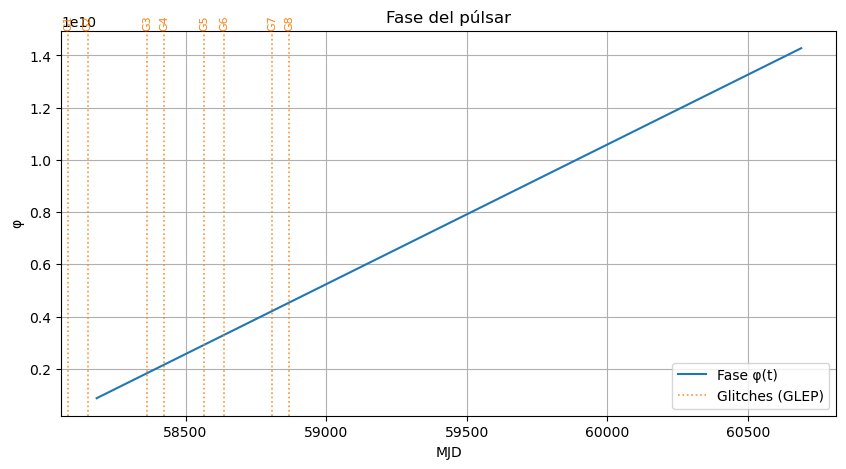

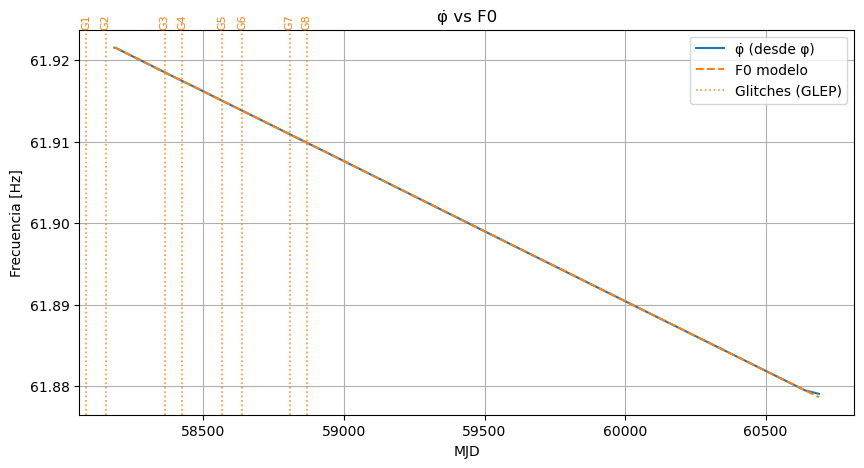

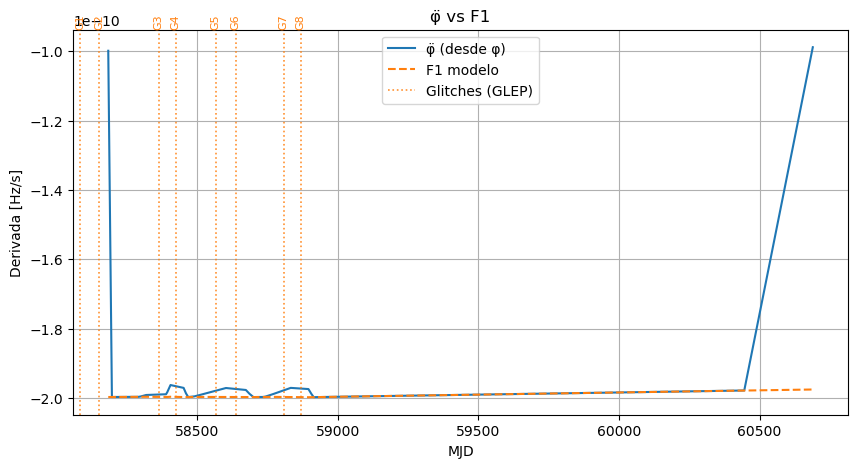

In [13]:
# -----------------------------------------------------------------
# GRAFICOS
# -----------------------------------------------------------------

# φ(t)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(datos['mjd'], phi, label='Fase φ(t)')
marcar_glitches_en_grafico(ax, params, datos, CONFIG['GLITCHES_IGNORAR'])
ax.set_xlabel('MJD')
ax.set_ylabel('φ')
ax.set_title('Fase del púlsar')
ax.legend()
ax.grid()
plt.show()

# φ̇ vs F0
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(datos['mjd'], phi_dot, label='φ̇ (desde φ)')
ax.plot(datos['mjd'], f0_model, '--', label='F0 modelo')
marcar_glitches_en_grafico(ax, params, datos, CONFIG['GLITCHES_IGNORAR'])
ax.set_xlabel('MJD')
ax.set_ylabel('Frecuencia [Hz]')
ax.set_title('φ̇ vs F0')
ax.legend()
ax.grid()
plt.show()

# φ̈ vs F1
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(datos['mjd'], phi_ddot, label='φ̈ (desde φ)')
ax.plot(datos['mjd'], f1_model, '--', label='F1 modelo')
marcar_glitches_en_grafico(ax, params, datos, CONFIG['GLITCHES_IGNORAR'])
ax.set_xlabel('MJD')
ax.set_ylabel('Derivada [Hz/s]')
ax.set_title('φ̈ vs F1')
ax.legend()
ax.grid()
plt.show()


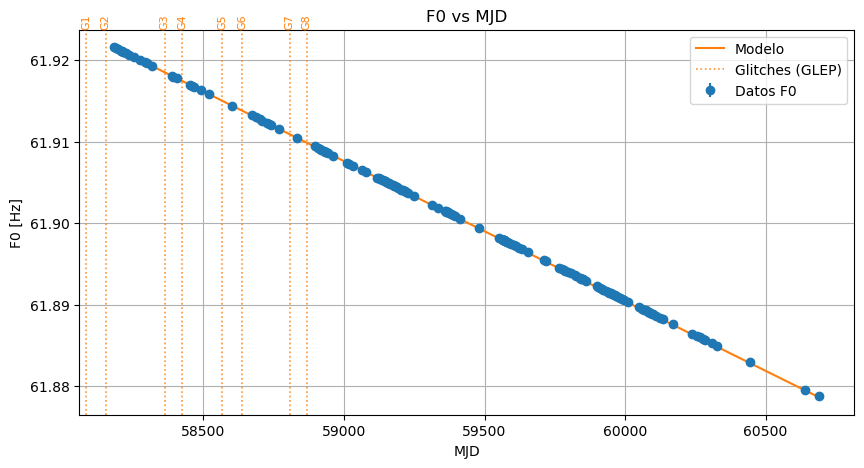

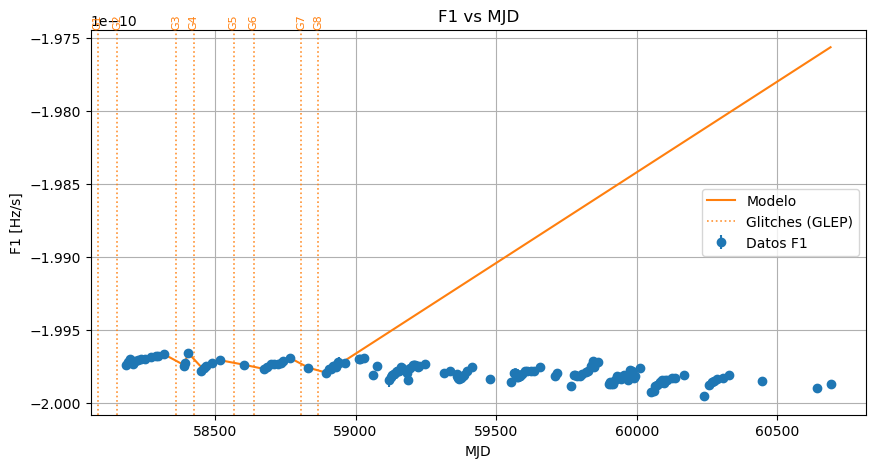

In [14]:
# Datos vs modelo: F0
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    datos['mjd'],
    datos['f0'],
    yerr=datos['err_f0'],
    fmt='o',
    label='Datos F0',
)
ax.plot(datos['mjd'], f0_model, label='Modelo')
marcar_glitches_en_grafico(ax, params, datos, CONFIG['GLITCHES_IGNORAR'])
ax.set_xlabel('MJD')
ax.set_ylabel('F0 [Hz]')
ax.set_title('F0 vs MJD')
ax.legend()
ax.grid()
plt.show()

# Datos vs modelo: F1
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    datos['mjd'],
    datos['f1'],
    yerr=datos['err_f1'],
    fmt='o',
    label='Datos F1',
)
ax.plot(datos['mjd'], f1_model, label='Modelo')
marcar_glitches_en_grafico(ax, params, datos, CONFIG['GLITCHES_IGNORAR'])
ax.set_xlabel('MJD')
ax.set_ylabel('F1 [Hz/s]')
ax.set_title('F1 vs MJD')
ax.legend()
ax.grid()
plt.show()


---
## 4. Resumen de glitches leídos desde el archivo `.par`

Se imprime el resumen de los glitches extraídos del modelo. Para cada evento se muestra su índice, la época `GLEP` en MJD, su estado según la configuración del notebook y su ubicación respecto del intervalo temporal del archivo `.dat`.

Esta revisión permite comprobar qué glitches están siendo considerados antes de interpretar los gráficos.


In [28]:
imprimir_resumen_glitches(
    params,
    datos,
    CONFIG['GLITCHES_IGNORAR'],
)


Resumen de glitches
-------------------
Glitches detectados en el .par: 8
Intervalo observado (.dat): MJD 58183.513614 – 60689.433322
G1: GLEP=58083.000000 MJD | activo | antes del primer dato observado | GLF0=1.612e-05, GLF1=-1.500e-13, GLF2=0.000e+00
G2: GLEP=58152.000000 MJD | activo | antes del primer dato observado | GLF0=3.603e-05, GLF1=-1.650e-13, GLF2=-4.364e-21
G3: GLEP=58363.000000 MJD | activo | dentro del rango observado | GLF0=7.829e-06, GLF1=-2.288e-13, GLF2=5.383e-20
G4: GLEP=58424.000000 MJD | activo | dentro del rango observado | GLF0=2.533e-05, GLF1=-2.141e-13, GLF2=-5.132e-20
G5: GLEP=58566.000000 MJD | activo | dentro del rango observado | GLF0=9.213e-06, GLF1=-9.520e-14, GLF2=2.000e-21
G6: GLEP=58637.000000 MJD | activo | dentro del rango observado | GLF0=2.699e-05, GLF1=-8.651e-14, GLF2=-1.341e-21
G7: GLEP=58807.000000 MJD | activo | dentro del rango observado | GLF0=7.565e-06, GLF1=-2.213e-13, GLF2=4.876e-20
G8: GLEP=58868.000000 MJD | activo | dentro del rango o

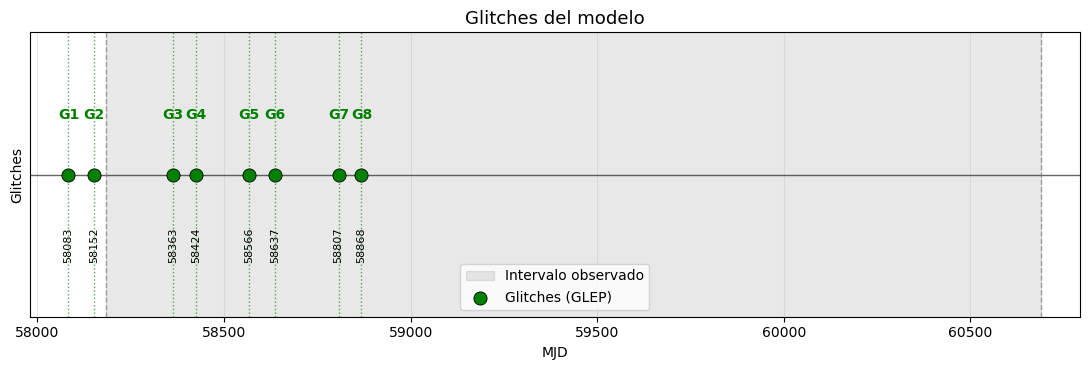

In [29]:
if "params" not in globals():
    params, _ = leer_par(CONFIG["PAR_FILE"])

if "datos" not in globals():
    datos, _ = leer_dat(CONFIG["DAT_FILE"])


def graficar_glitches_mjd(params, datos=None):
    """
    Grafica los glitches leídos desde el archivo .par en función del MJD.

    Cada glitch se representa mediante su época GLEP y todos se muestran
    sobre una misma línea temporal.
    """

    glitches = params.get("glitches", [])

    if len(glitches) == 0:
        print("No se encontraron glitches en el archivo .par.")
        return

    glitch_indices = []
    glitch_mjd = []

    for i, glitch in enumerate(glitches, start=1):

        if "GLEP" not in glitch:
            continue

        glitch_indices.append(i)
        glitch_mjd.append(float(glitch["GLEP"]))

    if len(glitch_mjd) == 0:
        print("Se encontraron glitches, pero ninguno contiene GLEP.")
        return

    glitch_indices = np.array(glitch_indices)
    glitch_mjd = np.array(glitch_mjd)

    orden = np.argsort(glitch_mjd)

    glitch_indices = glitch_indices[orden]
    glitch_mjd = glitch_mjd[orden]

    # --------------------------------------------------------------
    # Rango temporal del archivo .dat
    # --------------------------------------------------------------

    if datos is not None and "mjd" in datos and len(datos["mjd"]) > 0:

        mjd_min = float(np.min(datos["mjd"]))
        mjd_max = float(np.max(datos["mjd"]))

    else:

        mjd_min = None
        mjd_max = None

    # --------------------------------------------------------------
    # Figura
    # --------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(11, 3.8))

    color_glitch = "green"

    # Línea temporal base
    ax.axhline(
        y=0,
        color="black",
        linewidth=1.0,
        alpha=0.6,
    )

    # Intervalo observado del .dat
    if mjd_min is not None and mjd_max is not None:

        ax.axvspan(
            mjd_min,
            mjd_max,
            color="gray",
            alpha=0.18,
            label="Intervalo observado",
        )

        ax.axvline(
            mjd_min,
            color="gray",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7,
        )

        ax.axvline(
            mjd_max,
            color="gray",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7,
        )

    # Glitches sobre la misma línea temporal
    ax.scatter(
        glitch_mjd,
        np.zeros_like(glitch_mjd),
        s=90,
        color=color_glitch,
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
        label="Glitches (GLEP)",
    )

    # Líneas verticales y etiquetas
    for idx, mjd_g in zip(glitch_indices, glitch_mjd):

        ax.axvline(
            mjd_g,
            color=color_glitch,
            linestyle=":",
            linewidth=1.0,
            alpha=0.65,
        )

        ax.text(
            mjd_g,
            0.13,
            f"G{idx}",
            color=color_glitch,
            fontsize=10,
            ha="center",
            va="bottom",
            fontweight="bold",
        )

        ax.text(
            mjd_g,
            -0.13,
            f"{mjd_g:.0f}",
            color="black",
            fontsize=8,
            ha="center",
            va="top",
            rotation=90,
        )

    # --------------------------------------------------------------
    # Formato del gráfico
    # --------------------------------------------------------------

    ax.set_title(
        "Glitches del modelo",
        fontsize=13,
    )

    ax.set_xlabel("MJD")
    ax.set_ylabel("Glitches")

    ax.set_yticks([])

    ax.grid(
        True,
        axis="x",
        alpha=0.3,
    )

    ax.set_ylim(-0.35, 0.35)

    x_min = np.min(glitch_mjd)
    x_max = np.max(glitch_mjd)

    if mjd_min is not None and mjd_max is not None:
        x_min = min(x_min, mjd_min)
        x_max = max(x_max, mjd_max)

    margen = 0.04 * (x_max - x_min)

    if margen == 0:
        margen = 1.0

    ax.set_xlim(
        x_min - margen,
        x_max + margen,
    )

    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()


graficar_glitches_mjd(
    params=params,
    datos=datos,
)
#El area sombreada es el intervalo de MJD que coincide entre los archivos y los Glitches